# Pictures for the article in Stromingen

First execute part of mf_adapt.py

In [ ]:
# %% --- imports
import os
import sys
import numpy as np
import time
from pathlib import Path
import logging
from mf6_bootstrap import activate # noqa: F401

activate(verbose=True) # noqa: RUF100

# --- Imports are not missing after activate(__file__)
# ruff: noqa: E402

from settings import props      # pyright: ignore[reportMissingImports]      
from timing import log_timed    # pyright: ignore[reportMissingImports]
from mf6tools import Dirs       # pyright: ignore[reportMissingImports]
import ggor_tools as ggt        # pyright: ignore[reportMissingImports]
from logging_setup import configure_logging # pyright: ignore[reportMissingImports]

# --- setting up the logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
configure_logging()

def get_case_name():
    parts = Path.cwd().parts
    return parts[parts.index('mf6lab') + 4]



[mf6_bootstrap] Activated
Caller: /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/src/JUPYTER_FAKE_CALLER.py
Added paths:
 • /Users/Theo/GRWMODELS/python/mf6lab/src
 • /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/src
 • /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/src


In [6]:

# --- Rest of the script
case_name = get_case_name()
parts = Path.cwd().parts
parts[parts.index('mf6lab') + 4]

start_script = time.perf_counter()

logger.info("Running module as a script")

dirs = Dirs()
dirs.meteo = os.path.join(Path(dirs.proj).parent, 'data', 'meteo')
dirs.bofek = os.path.join(Path(dirs.proj).parent, 'data', 'bofek')


# %% --- tdis ======  time discretization
with log_timed(logger, 'tdata generated and pickled'):
    tdata = ggt.get_tdata(dirs=dirs,  stn=240,
                  start='20100101', end='20191231',
                  folder=dirs.meteo)
    tdata_file = os.path.join(dirs.data, 'tdata.pkl')
    tdata.to_pickle(tdata_file)
    
with log_timed(logger, "Parcel_data generated and pickled"):
    parcel_data = ggt.get_parcel_data(dirs=dirs, defaults=ggt.defaults, BMINMAX=(5, 250))
    pdata_file = os.path.join(dirs.data, 'parcel_data.pkl')
    parcel_data.to_pickle(pdata_file)

start_date_time = str(tdata.index[0])

nper, nstep, tsmult = len(tdata), 1, 1.0

# --- Because we change boundary conditions, nper > 0
dt = np.diff(tdata.index - tdata.index[0]) / np.timedelta64(1, 'D')
dt = np.hstack((dt[0], dt)) # Assume dt[0] ==  t[1] - t[0])

period_data = [[sp_time, nstep, tsmult] for sp_time in dt]

Simtdis = {'perioddata': period_data,
           'nper': len(period_data),
           'start_date_time': start_date_time,
           'time_units': props['time_units'],
           }

with log_timed(logger, "grid generated"):
    gr = ggt.grid_from_parcel_data(parcel_data=parcel_data,
                                   dx=props['dx'])


20:23:15 [INFO] Running module as a script
20:23:15 [INFO] tdata generated and pickled in 0.04 seconds


folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/data already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/doc already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/GIS already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/GWF already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/GWT already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/meteo already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/MP7 already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/images already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/notebooks already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/SIM already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/src already exist

20:23:16 [INFO] Parcel_data generated and pickled in 0.48 seconds
20:23:16 [INFO] grid generated in 0.00 seconds


# Plot the ggor grid for AAN_GZK (Gooise Zomer Kade)

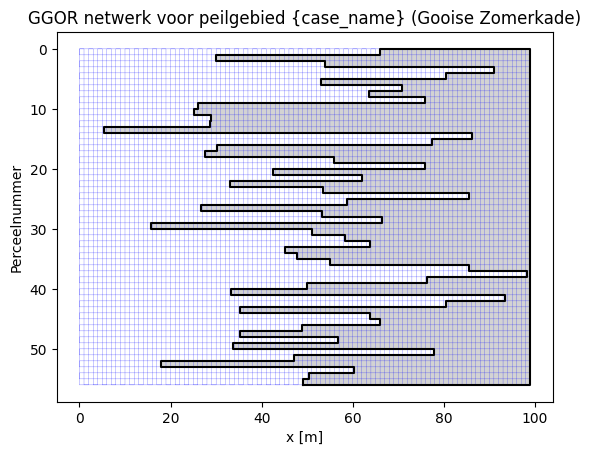

In [7]:
import matplotlib.pyplot as plt
from matplotlib import patches

gr.plot_grid(color='b', lw=0.15)

ax = plt.gca()
ax.invert_yaxis()

b = parcel_data['b'].values
B = np.vstack((b, b)).T.flatten()
Y = np.vstack((gr.y[:-1], gr.y[1:])).T.flatten()
X = gr.x[-1] * np.ones_like(Y)
ax.plot(np.hstack((B, X, B[0])), np.hstack((Y, Y[::-1], Y[0])), 'k')

x_, y_ = np.hstack((B, X, B[0])), np.hstack((Y, Y[::-1], Y[0]))

poly = patches.Polygon([(x, y) for x, y in zip(x_, y_)],
                    closed=True,
                    facecolor='lightgray')
ax.add_patch(poly)
ax.set_ylabel('Perceelnummer')
ax.set_title('GGOR netwerk voor peilgebied {case_name} (Gooise Zomerkade)')
ax.figure.savefig(os.path.join(dirs.images, 'grid_AAN_GKZ.png'))


In [ ]:
def check_caller():

    parts = Path(os.getcwd()).parts
    try:
        case_name = parts[parts.index('mf6lab') + 4]
        return case_name
    except IndexError:
        raise IndexError(f"Cwd not in mflab_hierarch: {'/'.join(parts)}")



In [ ]:
p = Path.cwd().resolve()
for cur in [p] + list(p.parents):
    print(k)




In [ ]:
Path.cwd()